<a href="https://colab.research.google.com/github/Fushionek/DataAnalysis/blob/main/DataAnalysis/Anime_List/AnimeListAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

path = kagglehub.dataset_download("itszubi/anime-myanimelist-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.65M/2.65M [00:00<00:00, 128MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/itszubi/anime-myanimelist-dataset/versions/1


In [ ]:
df = pd.read_csv(path + "/anime.csv")
df.head()

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anime_id    10000 non-null  int64  
 1   title       10000 non-null  object 
 2   score       10000 non-null  float64
 3   rank        10000 non-null  int64  
 4   popularity  10000 non-null  int64  
 5   members     10000 non-null  int64  
 6   synopsis    9998 non-null   object 
 7   start_date  9998 non-null   object 
 8   end_date    9916 non-null   object 
 9   type        10000 non-null  object 
 10  episodes    9952 non-null   float64
 11  image_url   10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


In [ ]:
df['start_date'] = df['start_date'].astype('datetime64[ns]')
df['end_date'] = df['end_date'].astype('datetime64[ns]')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   anime_id    10000 non-null  int64         
 1   title       10000 non-null  object        
 2   score       10000 non-null  float64       
 3   rank        10000 non-null  int64         
 4   popularity  10000 non-null  int64         
 5   members     10000 non-null  int64         
 6   synopsis    9998 non-null   object        
 7   start_date  9998 non-null   datetime64[ns]
 8   end_date    9916 non-null   datetime64[ns]
 9   type        10000 non-null  object        
 10  episodes    9952 non-null   float64       
 11  image_url   10000 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [ ]:
df.isnull().sum()

,0
anime_id,0
title,0
score,0
rank,0
popularity,0
members,0
synopsis,2
start_date,2
end_date,84
type,0


In [ ]:
df

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1351,Angel Cop,6.05,9994,4755,26983,"Sometime in the future, terrorism in Japan has...",1989-01-01,1994-01-01,OVA,6.0,https://cdn.myanimelist.net/images/anime/1377/...
9996,33339,Zhongguo Jingqi Xiansheng,6.05,9991,10781,3192,A lost form of magic is revived from the Easte...,2014-01-01,2016-01-01,ONA,63.0,https://cdn.myanimelist.net/images/anime/1637/...
9997,2840,Youkoso Lodoss-tou e!,6.05,9988,11348,2710,This movie is the compilation of the 27 mini-p...,1998-01-01,1998-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/7/613...
9998,33764,Ying Xiong Bie Nao,6.05,9987,17963,502,The series takes place on a parallel world fil...,2015-01-01,2015-01-01,ONA,13.0,https://cdn.myanimelist.net/images/anime/1013/...


In [ ]:
df['Ongoing'] = df['end_date'].isnull()

In [ ]:
df

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url,Ongoing
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...,False
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...,False
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...,False
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...,False
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1351,Angel Cop,6.05,9994,4755,26983,"Sometime in the future, terrorism in Japan has...",1989-01-01,1994-01-01,OVA,6.0,https://cdn.myanimelist.net/images/anime/1377/...,False
9996,33339,Zhongguo Jingqi Xiansheng,6.05,9991,10781,3192,A lost form of magic is revived from the Easte...,2014-01-01,2016-01-01,ONA,63.0,https://cdn.myanimelist.net/images/anime/1637/...,False
9997,2840,Youkoso Lodoss-tou e!,6.05,9988,11348,2710,This movie is the compilation of the 27 mini-p...,1998-01-01,1998-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/7/613...,False
9998,33764,Ying Xiong Bie Nao,6.05,9987,17963,502,The series takes place on a parallel world fil...,2015-01-01,2015-01-01,ONA,13.0,https://cdn.myanimelist.net/images/anime/1013/...,False


In [ ]:
df[df['Ongoing']]

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url,Ongoing
19,61517,Kingdom 6th Season,9.06,5,4855,25549,"In ancient China, during the Warring States pe...",2025-01-01,NaT,TV,NaN,https://cdn.myanimelist.net/images/anime/1282/...,True
60,21,One Piece,8.73,51,17,2604623,Barely surviving in a barrel after passing thr...,1999-01-01,NaT,TV,NaN,https://cdn.myanimelist.net/images/anime/1244/...,True
167,50250,Chiikawa,8.47,166,6088,14307,"What's a Chiikawa? No one really knows, but ev...",2022-01-01,NaT,TV,NaN,https://cdn.myanimelist.net/images/anime/1783/...,True
181,51039,Doupo Cangqiong: Nian Fan,8.44,186,6660,11568,Fifth season of Doupo Cangqiong .,2022-01-01,NaT,ONA,209.0,https://cdn.myanimelist.net/images/anime/1419/...,True
188,60988,Tian Guan Cifu Short Film,8.45,183,7134,9814,A short film celebrating the fourth anniversar...,2025-01-01,NaT,ONA,NaN,https://cdn.myanimelist.net/images/anime/1174/...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9543,60947,Nmeneko,6.13,9545,15942,755,Follows the funny and amusing daily lives of t...,2025-01-01,NaT,TV,NaN,https://cdn.myanimelist.net/images/anime/1989/...,True
9560,61067,Ninja to Gokudou,6.13,9544,6611,11731,"Since ancient times, the ninja and the yakuza ...",2025-01-01,NaT,TV,NaN,https://cdn.myanimelist.net/images/anime/1296/...,True
9572,42295,Fushigi Dagashiya: Zenitendou,6.13,9576,11935,2294,Zenitendo is a mysterious candy store that onl...,2020-01-01,NaT,TV,NaN,https://cdn.myanimelist.net/images/anime/1602/...,True
9637,37300,Xiao Liyu Lixian Ji,6.11,9642,18486,459,"Bubbles, a carp, lives in Carp Lake with his g...",2007-01-01,NaT,TV,52.0,https://cdn.myanimelist.net/images/anime/1305/...,True


In [ ]:
df['release_year'] = df['start_date'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   anime_id      10000 non-null  int64         
 1   title         10000 non-null  object        
 2   score         10000 non-null  float64       
 3   rank          10000 non-null  int64         
 4   popularity    10000 non-null  int64         
 5   members       10000 non-null  int64         
 6   synopsis      9998 non-null   object        
 7   start_date    9998 non-null   datetime64[ns]
 8   end_date      9916 non-null   datetime64[ns]
 9   type          10000 non-null  object        
 10  episodes      9952 non-null   float64       
 11  image_url     10000 non-null  object        
 12  Ongoing       10000 non-null  bool          
 13  release_year  9998 non-null   float64       
dtypes: bool(1), datetime64[ns](2), float64(3), int64(4), object(4)
memory usage: 1.0+ MB


In [ ]:
df = df.dropna(subset=['synopsis','start_date'])

In [ ]:
df.isnull().sum()

,0
anime_id,0
title,0
score,0
rank,0
popularity,0
members,0
synopsis,0
start_date,0
end_date,82
type,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   anime_id      9996 non-null   int64         
 1   title         9996 non-null   object        
 2   score         9996 non-null   float64       
 3   rank          9996 non-null   int64         
 4   popularity    9996 non-null   int64         
 5   members       9996 non-null   int64         
 6   synopsis      9996 non-null   object        
 7   start_date    9996 non-null   datetime64[ns]
 8   end_date      9914 non-null   datetime64[ns]
 9   type          9996 non-null   object        
 10  episodes      9948 non-null   float64       
 11  image_url     9996 non-null   object        
 12  Ongoing       9996 non-null   bool          
 13  release_year  9996 non-null   float64       
dtypes: bool(1), datetime64[ns](2), float64(3), int64(4), object(4)
memory usage: 1.1+ MB


In [ ]:
df['title'] = df['title'].astype('string')
df['synopsis'] = df['synopsis'].astype('string')
df['type'] = df['type'].astype('category')

/tmp/ipykernel_4296/1843431433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['title'] = df['title'].astype('string')
/tmp/ipykernel_4296/1843431433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['synopsis'] = df['synopsis'].astype('string')
/tmp/ipykernel_4296/1843431433.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   anime_id      9996 non-null   int64         
 1   title         9996 non-null   string        
 2   score         9996 non-null   float64       
 3   rank          9996 non-null   int64         
 4   popularity    9996 non-null   int64         
 5   members       9996 non-null   int64         
 6   synopsis      9996 non-null   string        
 7   start_date    9996 non-null   datetime64[ns]
 8   end_date      9914 non-null   datetime64[ns]
 9   type          9996 non-null   category      
 10  episodes      9948 non-null   float64       
 11  image_url     9996 non-null   object        
 12  Ongoing       9996 non-null   bool          
 13  release_year  9996 non-null   float64       
dtypes: bool(1), category(1), datetime64[ns](2), float64(3), int64(4), object(1), string(2)
memory

In [ ]:
df.sort_values(by=['rank','score']).head()

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url,Ongoing,release_year
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...,False,2023.0
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...,False,2025.0
10,5114,Fullmetal Alchemist: Brotherhood,9.10,3,3,3602700,After a horrific alchemy experiment goes wrong...,2009-01-01,2010-01-01,TV,64.0,https://cdn.myanimelist.net/images/anime/1208/...,False,2009.0
28,9253,Steins;Gate,9.07,4,14,2755520,Eccentric scientist Rintarou Okabe has a never...,2011-01-01,2011-01-01,TV,24.0,https://cdn.myanimelist.net/images/anime/1935/...,False,2011.0
19,61517,Kingdom 6th Season,9.06,5,4855,25549,"In ancient China, during the Warring States pe...",2025-01-01,NaT,TV,NaN,https://cdn.myanimelist.net/images/anime/1282/...,True,2025.0


In [ ]:
df.groupby('type')['score'].agg(['mean','median','count']).sort_values(by=['mean'],ascending=False).round(2)

/tmp/ipykernel_4296/3032666357.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('type')['score'].agg(['mean','median','count']).sort_values(by=['mean'],ascending=False).round(2)


,mean,median,count
type,,,
TV,7.07,7.01,4329
Movie,7.07,7.05,1722
OVA,6.88,6.81,1170
ONA,6.88,6.75,1339
TV Special,6.79,6.67,433
Special,6.79,6.71,1003


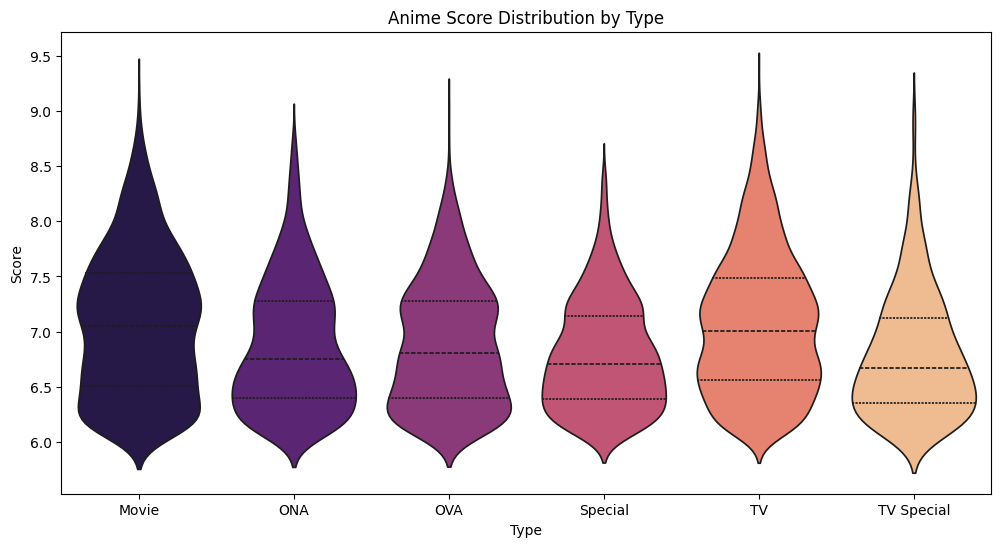

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.violinplot(x='type', y='score', data=df, palette='magma',hue='type', inner='quartile')
plt.title('Anime Score Distribution by Type')
plt.xlabel('Type')
plt.ylabel('Score')
plt.show()

In [ ]:
df

,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url,Ongoing,release_year
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...,False,2015.0
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...,False,2025.0
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...,False,2011.0
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...,False,2023.0
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...,False,2011.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1351,Angel Cop,6.05,9994,4755,26983,"Sometime in the future, terrorism in Japan has...",1989-01-01,1994-01-01,OVA,6.0,https://cdn.myanimelist.net/images/anime/1377/...,False,1989.0
9996,33339,Zhongguo Jingqi Xiansheng,6.05,9991,10781,3192,A lost form of magic is revived from the Easte...,2014-01-01,2016-01-01,ONA,63.0,https://cdn.myanimelist.net/images/anime/1637/...,False,2014.0
9997,2840,Youkoso Lodoss-tou e!,6.05,9988,11348,2710,This movie is the compilation of the 27 mini-p...,1998-01-01,1998-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/7/613...,False,1998.0
9998,33764,Ying Xiong Bie Nao,6.05,9987,17963,502,The series takes place on a parallel world fil...,2015-01-01,2015-01-01,ONA,13.0,https://cdn.myanimelist.net/images/anime/1013/...,False,2015.0


In [ ]:
y_avg = df.groupby('release_year')['score'].mean()

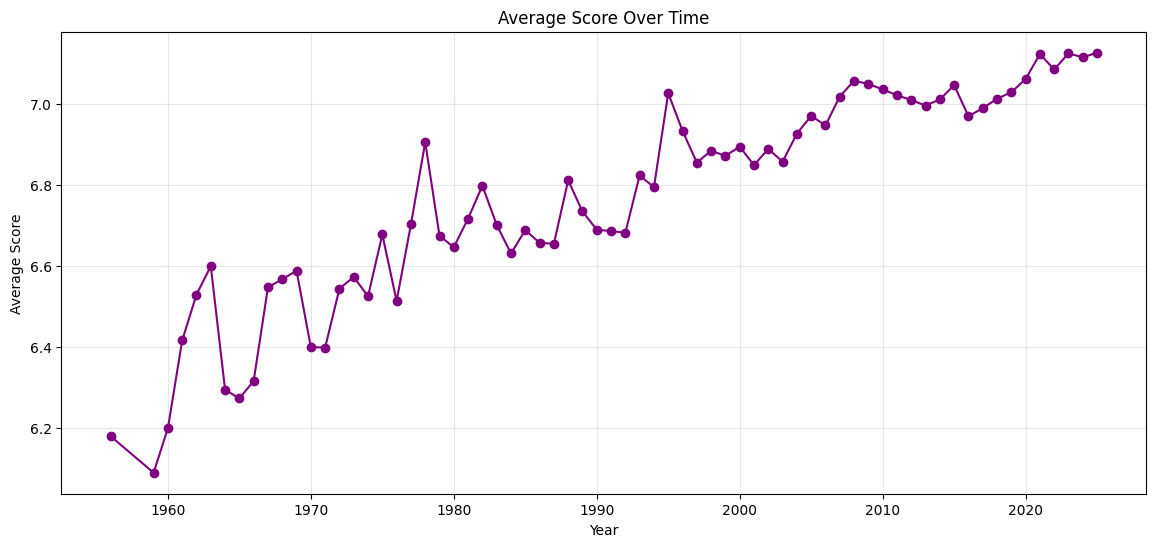

In [ ]:
plt.figure(figsize=(14, 6))
y_avg.plot(kind='line', marker='o', color='purple')
plt.title('Average Score Over Time')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
ongoing_finished = df.groupby('Ongoing')['score'].agg(['mean', 'median', 'count'])
print(ongoing_finished)

             mean  median  count
Ongoing                         
False    6.979123    6.90   9914
True     7.190366    7.17     82


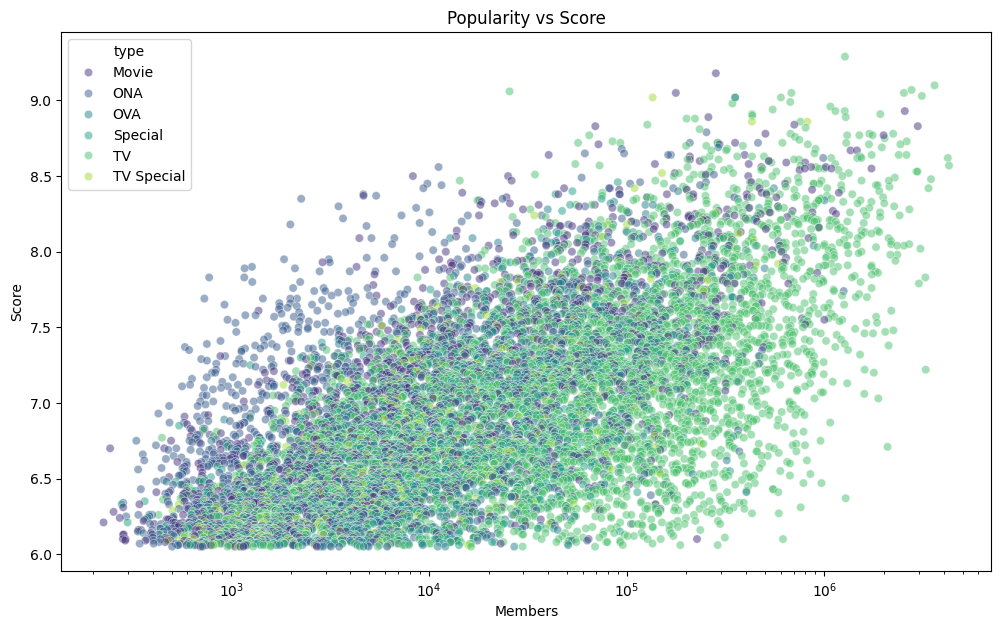

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='members', y='score', data=df, alpha=0.5, hue='type', palette='viridis')
plt.xscale('log')
plt.title('Popularity vs Score')
plt.xlabel('Members')
plt.ylabel('Score')
plt.show()

In [ ]:
score_top = 8.0

popularity_cutoff = df['members'].quantile(0.25)
min_members = 1000

hidden_gems = df[(df['score'] >= score_top) & (df['members'] < popularity_cutoff) & (df['members'] >= min_members)]

hidden_gems = hidden_gems.sort_values(by='score', ascending=False)

print(f"Found {len(hidden_gems)} 'hidden gems'.")
print(hidden_gems[['title', 'score', 'members']].head(10))

Found 4 'hidden gems'.
                                     title  score  members
272  Fanren Xiu Xian Chuan: Waihai Fengyun   8.35     2257
308  Fanren Xiu Xian Chuan: Xinghai Feichi   8.30     3487
407           Yi Nian Yong Heng 3rd Season   8.22     3676
431                         Cang Yuan Tu 2   8.18     1989


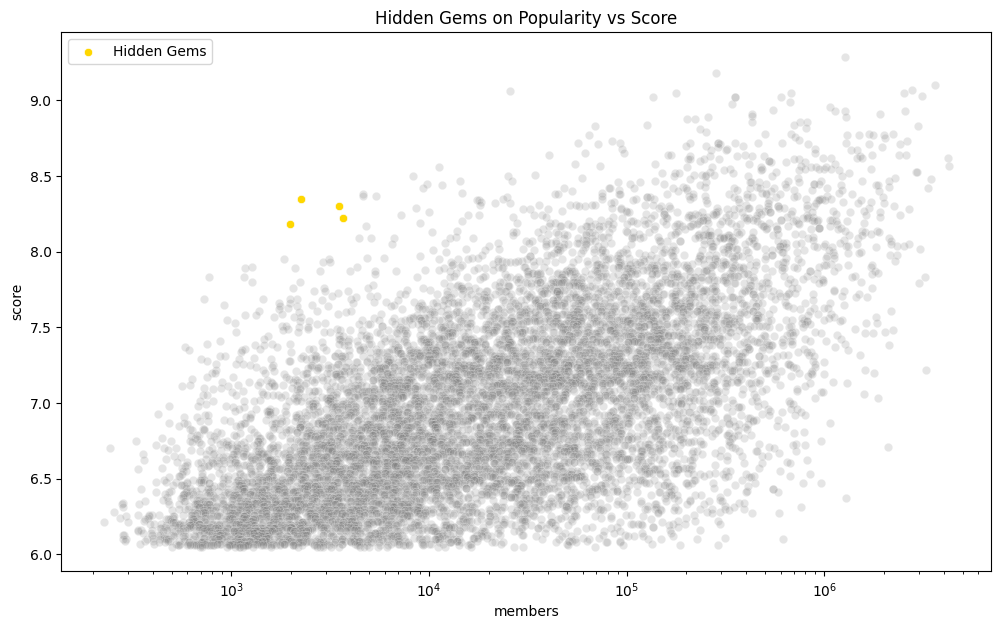

In [ ]:
plt.figure(figsize=(12, 7))

sns.scatterplot(x='members', y='score', data=df, alpha=0.2, color='gray')

sns.scatterplot(x='members', y='score', data=hidden_gems, color='gold', label='Hidden Gems')

plt.xscale('log')
plt.title('Hidden Gems on Popularity vs Score')
plt.show()